In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

------
## Main sample

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_lrg_1.1.1_pzbins_20221204.fits'))
photom = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_lrg_1.1.1_photom.fits', columns=['MORPHTYPE', 'FIBERFLUX_Z']))
cat = hstack([cat, photom], join_type='exact')
cat.rename_column('MORPHTYPE', 'TYPE')
print(len(cat))

12338990


In [4]:
mask = cat['pz_bin']!=-1
cat = cat[mask]
print(len(cat))

11046611


In [5]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [6]:
tmp = Table()
tmp['type'], tmp['count'] = np.unique(cat['TYPE'], return_counts=True)
tmp['frac (%)'] = tmp['count']/len(cat)*100
tmp['frac (%)'].format = '%.1f'
tmp.pprint_all()

type  count  frac (%)
---- ------- --------
 DEV 4811284     43.6
 EXP 1146187     10.4
 PSF  387007      3.5
 REX 3361380     30.4
 SER 1340753     12.1


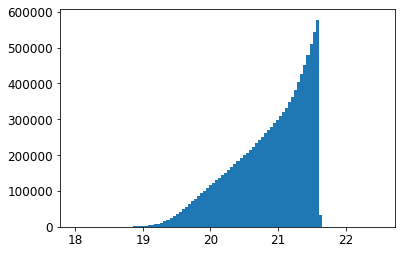

In [7]:
plt.hist(cat['zfibermag'], 100, range=(18, 22.5));

In [8]:
mask = cat['zfibermag']>21.55
tmp = Table()
tmp['type'], tmp['count'] = np.unique(cat['TYPE'][mask], return_counts=True)
tmp['frac (%)'] = tmp['count']/np.sum(mask)*100
tmp['frac (%)'].format = '%.1f'
tmp.pprint_all()

type count  frac (%)
---- ------ --------
 DEV 181768     27.0
 EXP 100034     14.9
 PSF  41848      6.2
 REX 342554     50.9
 SER   6813      1.0


------
## Extended sample

In [15]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_extended_lrg_0.49.0_pzbins_20230120.fits'))
photom = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_photom.fits', columns=['MORPHTYPE', 'FIBERFLUX_Z']))
cat = hstack([cat, photom], join_type='exact')
cat.rename_column('MORPHTYPE', 'TYPE')
print(len(cat))

35354635


In [16]:
mask = cat['extended_lrg']==True
mask &= cat['pz_bin']!=-1
cat = cat[mask]
print(len(cat))

27201667


In [17]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [18]:
tmp = Table()
tmp['type'], tmp['count'] = np.unique(cat['TYPE'], return_counts=True)
tmp['frac (%)'] = tmp['count']/len(cat)*100
tmp['frac (%)'].format = '%.1f'
tmp.pprint_all()

type  count   frac (%)
---- -------- --------
 DEV  9175294     33.7
 EXP  3601504     13.2
 PSF  1435556      5.3
 REX 10750219     39.5
 SER  2239094      8.2


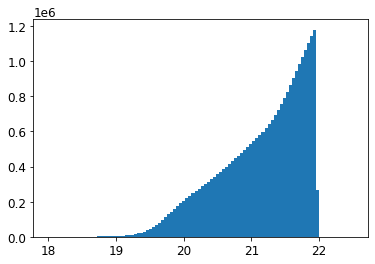

In [19]:
plt.hist(cat['zfibermag'], 100, range=(18, 22.5));

In [20]:
mask = cat['zfibermag']>21.9
tmp = Table()
tmp['type'], tmp['count'] = np.unique(cat['TYPE'][mask], return_counts=True)
tmp['frac (%)'] = tmp['count']/np.sum(mask)*100
tmp['frac (%)'].format = '%.1f'
tmp.pprint_all()

type  count  frac (%)
---- ------- --------
 DEV  231663     12.7
 EXP  278573     15.2
 PSF  239310     13.1
 REX 1073747     58.7
 SER    6869      0.4
